In [1]:
#%pip install pandas

In [2]:
#%pip install matplotlib seaborn

In [3]:
import pandas as pd
import glob

# 1. 지하철 승하차 데이터 통합
subway_files = glob.glob('CARD_SUBWAY_MONTH_*.csv')
subway_list = []
for f in subway_files:
    try:
        df = pd.read_csv(f, encoding='utf-8')
    except:
        df = pd.read_csv(f, encoding='cp949')
    subway_list.append(df)
subway_df = pd.concat(subway_list, ignore_index=True)

# [진짜 원본 복원] 컬럼 밀림 현상 강제 정렬 (순서 정확히 맞춤)
subway_df.columns = ['노선명', '역명', '승차총승객수', '하차총승객수', '사용일자', '등록일자']

# 2. 대기환경 데이터 통합
air_2025 = pd.read_csv('서울시 기간별 일평균 대기환경 정보_2025.csv', encoding='cp949')
air_2026 = pd.read_csv('서울시 기간별 일평균 대기환경 정보_2026.csv', encoding='cp949')
air_df = pd.concat([air_2025, air_2026], ignore_index=True)

print("✅ Step 1 완료")

✅ Step 1 완료


In [4]:
# 1. 날짜 데이터 형식 표준화
subway_df['날짜'] = pd.to_datetime(subway_df['사용일자'], format='%Y%m%d', errors='coerce')
subway_df = subway_df.dropna(subset=['날짜'])

air_df['날짜'] = pd.to_datetime(air_df['측정일자'], format='%Y%m%d', errors='coerce')
air_df = air_df.dropna(subset=['날짜'])

# 2. 분석 대상 6대 핵심 상권 역 필터링
target_stations = ['강남', '홍대입구', '성수', '명동', '압구정', '신촌']
commercial_subway = subway_df[subway_df['역명'].isin(target_stations)].copy()

# 3. 역별 일일 승하차 총객수 합산 처리
daily_commercial = commercial_subway.groupby(['날짜', '역명'])[['승차총승객수', '하차총승객수']].sum().reset_index()

print(f"✅ Step 2 완료 (확보된 지하철 데이터: {len(daily_commercial)}건)")

✅ Step 2 완료 (확보된 지하철 데이터: 1998건)


In [5]:
# 1. 역명 -> 자치구(측정소명) 1:1 매핑 사전 생성
station_to_gu = {
    '강남': '강남구', '홍대입구': '마포구',
    '성수': '성동구', '명동': '중구',
    '압구정': '강남구', '신촌': '마포구'
}

# 2. 지하철 데이터에 관할 측정소 정보 신규 부여
daily_commercial['측정소명'] = daily_commercial['역명'].map(station_to_gu)

print("✅ Step 3 완료")

✅ Step 3 완료


In [6]:
# 1. 강수량 데이터 전처리
rain_df = pd.read_csv('서울시 강수량 분석정보.csv', skiprows=7, encoding='cp949')
rain_df['날짜'] = pd.to_datetime(rain_df['날짜'])
daily_rain = rain_df.groupby('날짜')['강수량(mm)'].sum().reset_index()

# 2. [핵심] 대기환경 데이터 중복 제거 (메모리 폭발 방지)
air_df_unique = air_df.drop_duplicates(subset=['날짜', '측정소명']).copy()

# 3. 지하철 + 대기환경 데이터 정밀 병합 (날짜 & 측정소명 복합 키 기준)
merged_df = pd.merge(daily_commercial, air_df_unique, on=['날짜', '측정소명'], how='inner')

# 4. 강수량 데이터 최종 병합을 통한 통합 마스터셋 구축
final_master_df = pd.merge(merged_df, daily_rain, on='날짜', how='inner')

print("✅ Step 4 완료")

✅ Step 4 완료


In [7]:
# 1. 요일 계산 (0:월 ~ 6:일)
final_master_df['요일'] = final_master_df['날짜'].dt.dayofweek

# 2. 주말(5,6)이면서 강수량이 1.0mm 이하인 날만 필터링한다.
relaxed_weekend = final_master_df[(final_master_df['요일'] >= 5) & (final_master_df['강수량(mm)'] <= 1.0)].copy()

# 3. 미세먼지 등급 분류 함수 정의
def get_dust_grade(x):
    if x <= 30: return '좋음'
    elif x <= 80: return '보통'
    else: return '나쁨'

# 4. 최종 분석 표본에 먼지등급 부여
relaxed_weekend['먼지등급'] = relaxed_weekend['미세먼지(㎍/㎥)'].apply(get_dust_grade)

print("✅ Step 5 최종 가공 완료!")
print(f"최종 확보된 표본 건수: {len(relaxed_weekend)}건")

✅ Step 5 최종 가공 완료!
최종 확보된 표본 건수: 426건


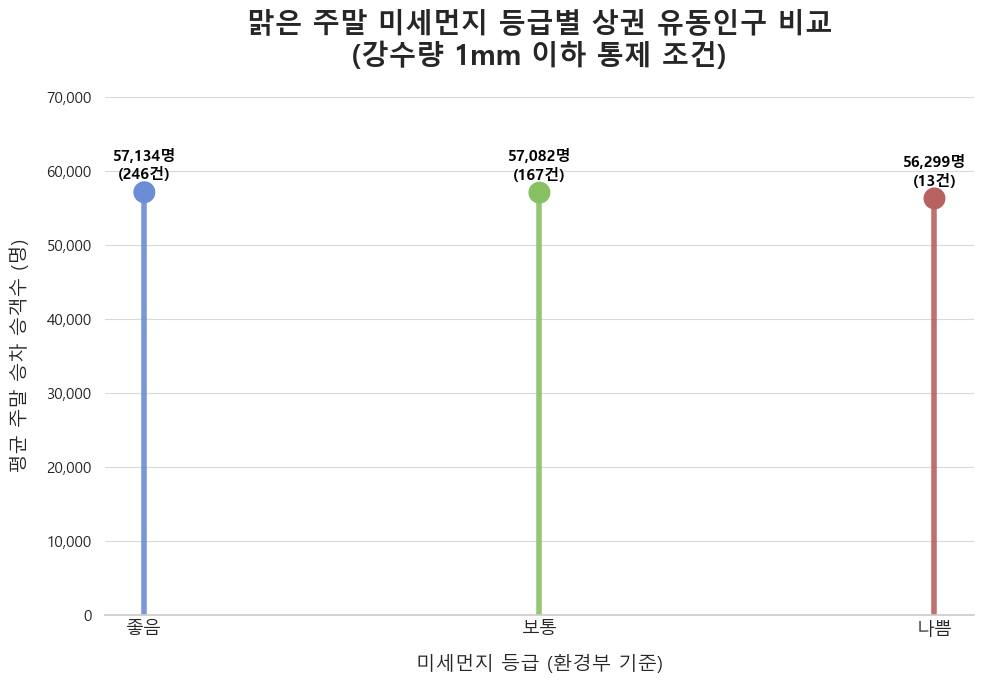

In [ ]:
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# 1. 기본 스타일 및 OS별 폰트 설정
sns.set_theme(style="whitegrid", context="notebook")

if sys.platform == 'darwin': # Mac OS 사용자 대비
    plt.rc('font', family='AppleGothic')
else: # Windows 사용자
    plt.rc('font', family='Malgun Gothic')
    
plt.rcParams['axes.unicode_minus'] = False

# 2. 지표별 수치는 relaxed_weekend 데이터프레임에서 직접 연산
order = ['좋음', '보통', '나쁨']

# 먼지등급별 승차총승객수 평균(mean)과 데이터 건수(count) 집계
grouped = relaxed_weekend.groupby('먼지등급')['승차총승객수'].agg(['mean', 'count']).reindex(order)

# 리스트 형태로 변환 (결측치가 발생할 경우를 대비해 0으로 처리)
y = grouped['mean'].fillna(0).tolist()
counts = grouped['count'].fillna(0).astype(int).tolist()

# 3. 색상 설정
colors = ['#6C8CD5', '#88C163', '#B86161']

# 4. 그래프 생성
fig, ax = plt.subplots(figsize=(10, 7))

# 로리팝 막대(세로선)
for i, val in enumerate(y):
    ax.vlines(x=i, ymin=0, ymax=val, color=colors[i], linewidth=4, alpha=0.9)

# 로리팝 머리(점)
ax.scatter(range(len(order)), y, s=220, color=colors, zorder=3)

# 5. 제목 / 축 라벨
ax.set_title(
    '맑은 주말 미세먼지 등급별 상권 유동인구 비교\n(강수량 1mm 이하 통제 조건)',
    fontsize=20,
    fontweight='bold',
    pad=22
)

ax.set_xlabel('미세먼지 등급 (환경부 기준)', fontsize=14, labelpad=12)
ax.set_ylabel('평균 주말 승차 승객수 (명)', fontsize=14, labelpad=12)

# 6. X축 설정
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, fontsize=13)

# 7. Y축 범위 자동 조정
max_y = max(y) if len(y) > 0 else 0
ax.set_ylim(0, max_y + 13000)

# 8. Y축 콤마 포맷
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: format(int(x), ',')))

# 9. 막대 위 텍스트 (소수점 제거를 위해 .0f 포맷 추가)
for i, val in enumerate(y):
    ax.text(
        i,
        val + 1200,
        f"{val:,.0f}명\n({counts[i]}건)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='black'
    )

# 10. 디자인 정리
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', visible=False)
ax.grid(axis='y', color='#D9D9D9', linewidth=0.8)
ax.tick_params(axis='x', length=0)

plt.tight_layout()
plt.show()